**Projet : Réseaux complexes et validation**

In [9]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from pathlib import Path
import tqdm
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
import sklearn

**Question 2.a : tracé de la distribution en degrées des réseaux Caltech, MIT et Johns Hopkins**

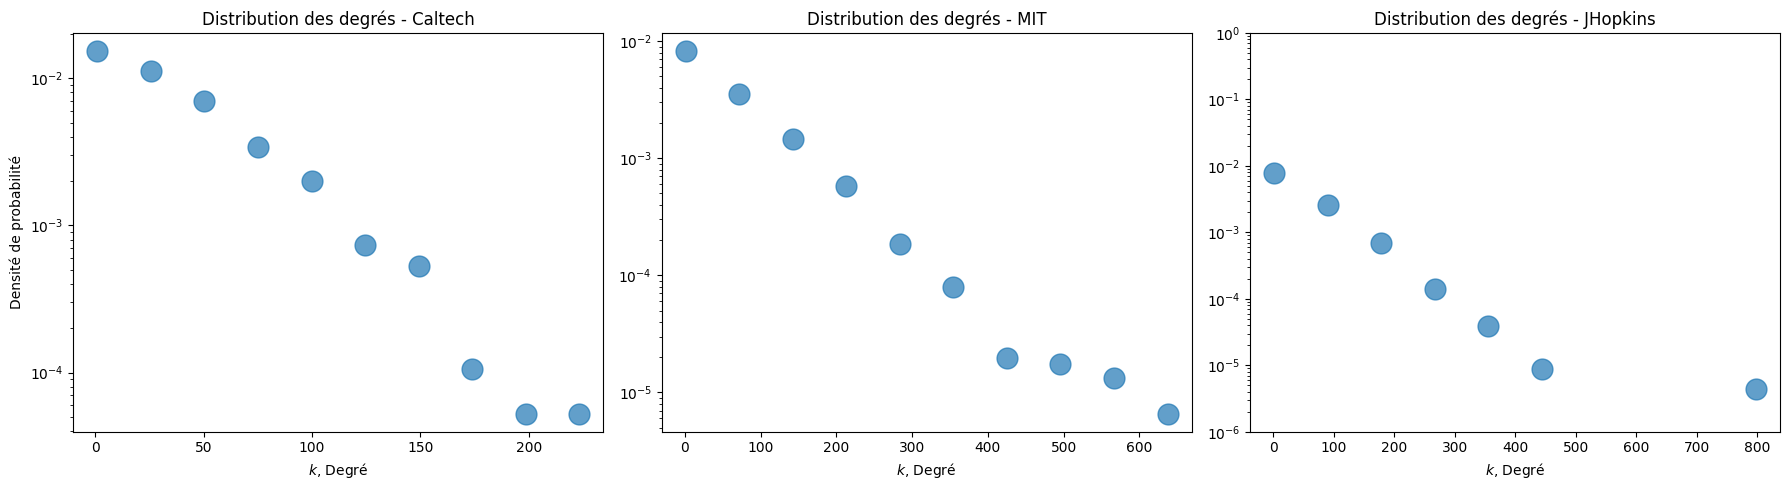

In [10]:
graphes = {}
Caltech = nx.read_gml("./fb100/data/Caltech36.gml")
graphes["Caltech"] = Caltech
mit = nx.read_gml("./fb100/data/MIT8.gml")
graphes["MIT"] = mit
JHopkins = nx.read_gml("./fb100/data/Johns Hopkins55.gml")
graphes["JHopkins"] = JHopkins

fix, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, G) in enumerate(graphes.items()):
    degrees = sorted([G.degree(node) for node in G.nodes()])
    hist, bins = np.histogram(degrees, density=True)
    axes[i].semilogy(bins[:-1], hist, marker="o", ms=15, linestyle="none", alpha=0.7)
    axes[i].set_xlabel(r"$k$, Degré")
    axes[i].set_title(f"Distribution des degrés - {name}")

    if i == 0:
        axes[i].set_ylabel(r"Densité de probabilité")
plt.ylim(1e-6, 1)
plt.tight_layout()
plt.show()

**Calculs de la transitivité, du clustering moyen et de la densité des 3 graphes**

In [11]:
for name, G in graphes.items():
    global_clustering = nx.transitivity(G)
    mean_clustering = nx.average_clustering(G)
    edge_density = nx.density(G)
    print(
        f"{name} - Clustering global: {global_clustering:.4f}, Clustering moyen: {mean_clustering:.4f}, Densité du graphe: {edge_density:.4f}"
    )

Caltech - Clustering global: 0.2913, Clustering moyen: 0.4093, Densité du graphe: 0.0564
MIT - Clustering global: 0.1803, Clustering moyen: 0.2712, Densité du graphe: 0.0121
JHopkins - Clustering global: 0.1932, Clustering moyen: 0.2684, Densité du graphe: 0.0139


**Question 2.b : Scatter plot du degré contre le coefficient de clustering local de chaque graphe**

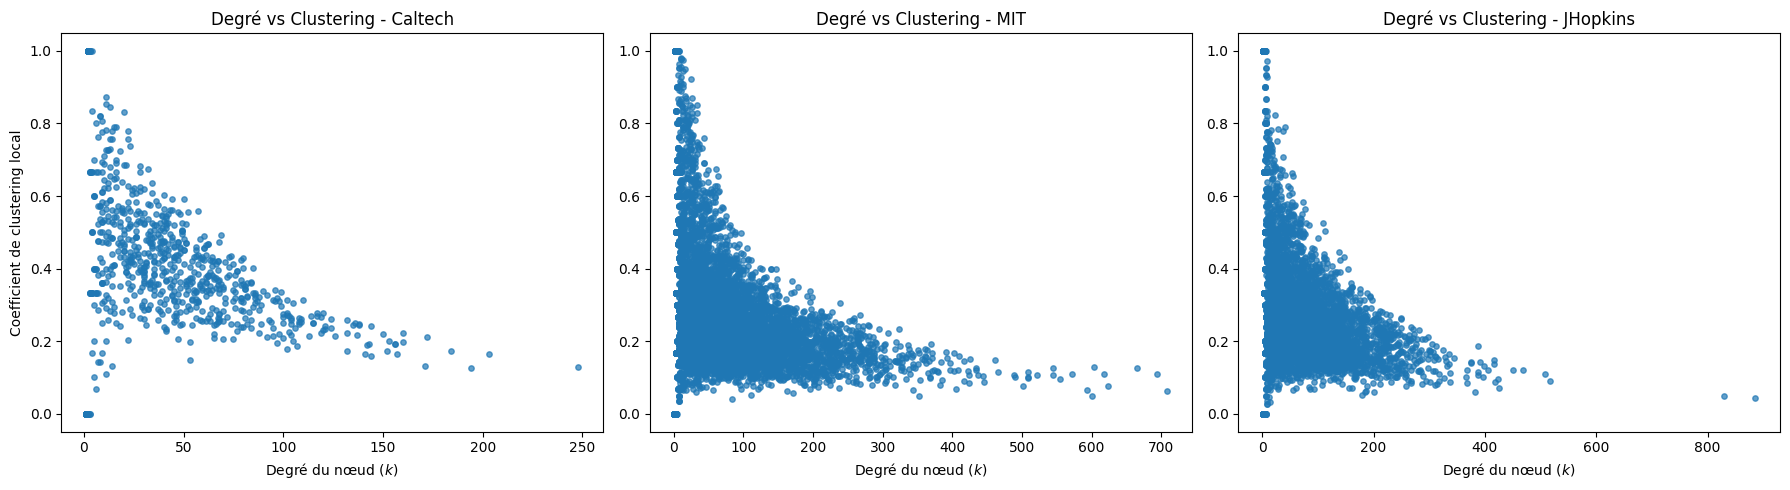

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, G) in enumerate(graphes.items()):
    degrees = [G.degree(n) for n in G.nodes()]
    clustering_coeffs = list(nx.clustering(G).values())

    axes[i].scatter(degrees, clustering_coeffs, alpha=0.7, s=15)
    axes[i].set_xlabel("Degré du nœud ($k$)")
    axes[i].set_title(f"Degré vs Clustering - {name}")
    if i == 0:
        axes[i].set_ylabel("Coefficient de clustering local")
plt.tight_layout()
plt.show()

**Question 3.a : Assortativity analysis**


In [13]:
def plot_assortativity(taille, assortativity, attribute):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.scatter(taille, assortativity, alpha=0.7, edgecolors="w", s=40)
    ax1.set_xscale("log")
    ax1.axhline(0, color="black", linestyle="--", label="No assortativity (0)")
    ax1.set_xlabel("Network size $n$ (log scale)")
    ax1.set_ylabel("Assortativity")
    ax1.set_title(f"Assortativity vs Network Size - {attribute}")
    ax1.legend()
    ax2.hist(assortativity, bins=20, color="skyblue", edgecolor="black", alpha=0.7)
    ax2.axvline(0, color="black", linestyle="--", label="No assortativity (0)")
    ax2.set_xlabel("Assortativity")
    ax2.set_ylabel("Frequency")
    ax2.set_title(f"Distribution of Assortativity - {attribute}")
    ax2.legend()
    plt.tight_layout()
    plt.show()

Traitement des graphes: 100%|██████████| 100/100 [17:12<00:00, 10.33s/it]


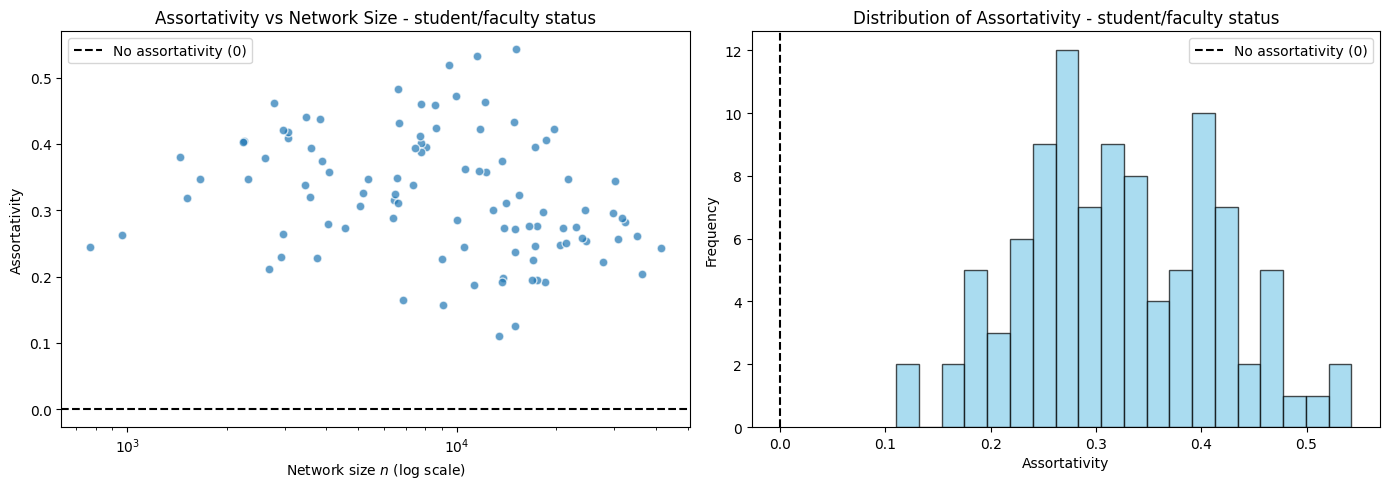

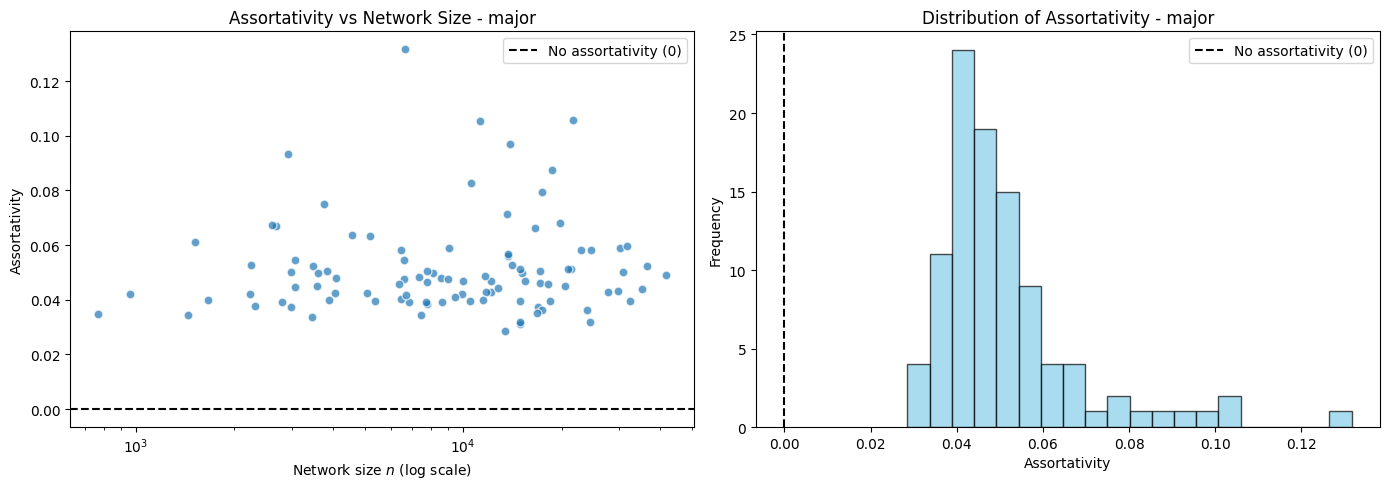

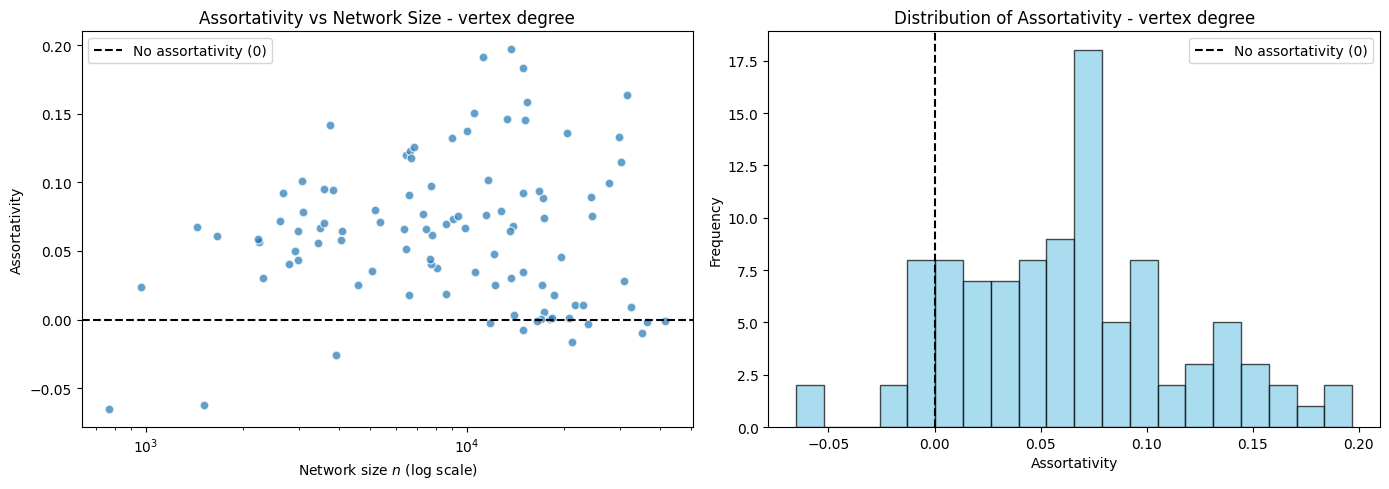

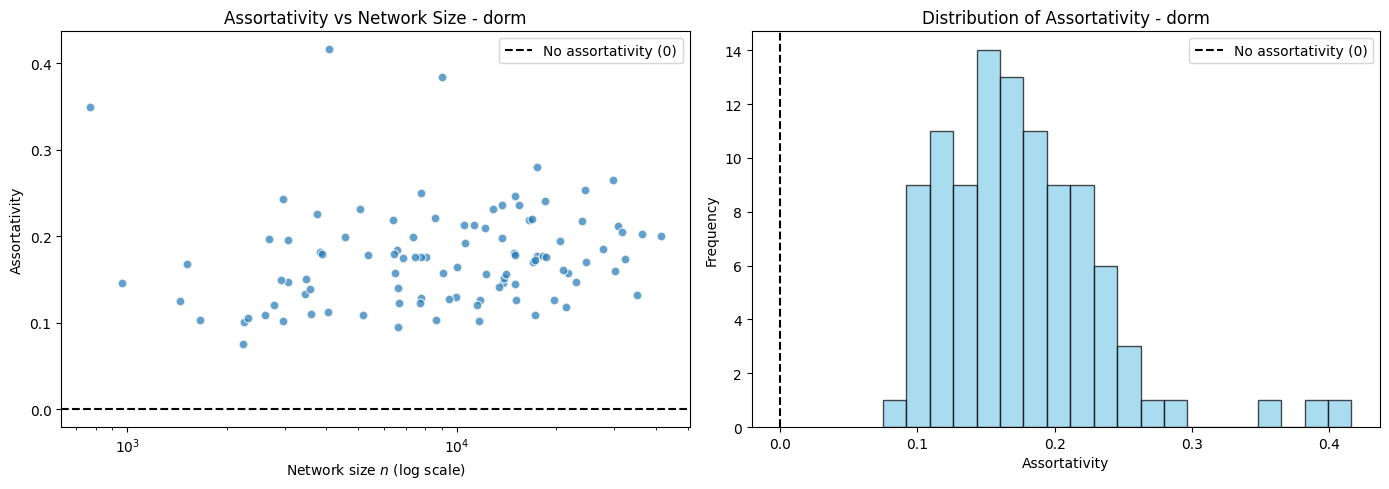

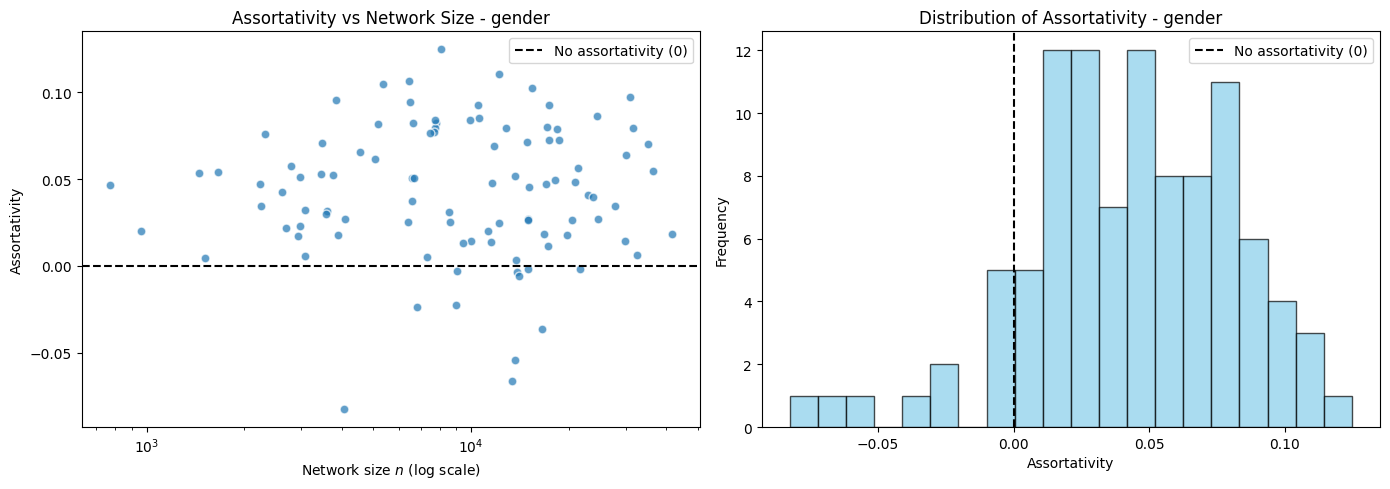

In [14]:
folder = Path("./fb100/data/")
graph_files = list(folder.glob("*.gml"))

taille = []
faculty_status = []
major = []
vertex_degree = []
dorm = []
gender = []

for file in tqdm.tqdm(graph_files, desc="Traitement des graphes"):
    G = nx.read_gml(file)
    taille.append(G.number_of_nodes())
    faculty_status.append(nx.attribute_assortativity_coefficient(G, "student_fac"))
    major.append(nx.attribute_assortativity_coefficient(G, "major_index"))
    vertex_degree.append(nx.degree_assortativity_coefficient(G))
    dorm.append(nx.attribute_assortativity_coefficient(G, "dorm"))
    gender.append(nx.attribute_assortativity_coefficient(G, "gender"))


plot_assortativity(taille, faculty_status, "student/faculty status")
plot_assortativity(taille, major, "major")
plot_assortativity(taille, vertex_degree, "vertex degree")
plot_assortativity(taille, dorm, "dorm")
plot_assortativity(taille, gender, "gender")


**Question 4.b : Implémentation des métriques de prédiction de liens Common Neighbors, Jaccard et Adamic/Adar**

In [ ]:
from abc import ABC
from abc import abstractmethod


class LinkPrediction(ABC):
    def __init__(self, graph):
        """
        Constructor
        Parameters
        ----------
        graph : Networkx graph
        """
        self.graph = graph
        self.N = len(graph)

    def neighbors(self, v):
        """
        Return the neighbors list of a node

        Parameters
        ----------
        v : int
        node idReturn
        ------
        neighbors_list : python list
        """
        neighbors_list = self.graph.neighbors(v)
        return list(neighbors_list)

    @abstractmethod
    def fit(self):
        raise NotImplementedError(" Fit must be implemented ")


class CommonNeighbors(LinkPrediction):
    def __init__(self, graph):
        super(CommonNeighbors, self).__init__(graph)

    def fit(self):

        non_linked_pairs = list(nx.non_edges(self.graph))
        A = nx.adjacency_matrix(self.graph)
        A_squared = A @ A

        node_list = list(self.graph.nodes())
        node_id = {node: id for id, node in enumerate(node_list)}

        predictions = []

        for u, v in tqdm.tqdm(non_linked_pairs, desc="Calculating common neighbors"):
            u_id = node_id[u]
            v_id = node_id[v]
            score = A_squared[u_id, v_id]
            predictions.append((u, v, score))
        predictions.sort(key=lambda x: x[2], reverse=True)
        return predictions


class JaccardCoefficient(LinkPrediction):
    def __init__(self, graph):
        super(JaccardCoefficient, self).__init__(graph)

    def fit(self):
        non_linked_pairs = list(nx.non_edges(self.graph))
        A = nx.adjacency_matrix(self.graph)
        A_squared = A @ A

        node_list = list(self.graph.nodes())
        node_id = {node: id for id, node in enumerate(node_list)}
        degrees = A.sum(axis=1)

        predictions = []

        for u, v in tqdm.tqdm(non_linked_pairs, desc="Calculating Jaccard coefficient"):
            u_id = node_id[u]
            v_id = node_id[v]
            common_neighbors = A_squared[u_id, v_id]
            union = degrees[u_id] + degrees[v_id] - common_neighbors
            if union > 0:
                score = common_neighbors / union
            else:
                score = 0.0
            predictions.append((u, v, score))
        predictions.sort(key=lambda x: x[2], reverse=True)
        return predictions


class AdamicAdar(LinkPrediction):
    def __init__(self, graph):
        super(AdamicAdar, self).__init__(graph)

    def fit(self):
        non_linked_pairs = list(nx.non_edges(self.graph))
        voisins = {n: set(self.graph.neighbors(n)) for n in self.graph.nodes()}

        predictions = []

        for u, v in tqdm.tqdm(non_linked_pairs, desc="Calculating Adamic-Adar index"):
            voisins_u = voisins[u]
            voisins_v = voisins[v]
            intersection = voisins_u.intersection(voisins_v)

            score = 0.0
            for z in intersection:
                degree_z = len(voisins[z])
                if degree_z > 1:
                    score += 1 / np.log(degree_z)
            predictions.append((u, v, score))
        predictions.sort(key=lambda x: x[2], reverse=True)
        return predictions

**Qestion 4.c : Évaluation des modèles de prédiction de liens**

In [ ]:
def graph_edit(G, f):
    G_copy = G.copy()
    edges = list(G_copy.edges())
    nb_to_remove = int(f * len(edges))
    random.shuffle(edges)
    removed_edges = edges[:nb_to_remove]
    G_copy.remove_edges_from(removed_edges)
    return G_copy, removed_edges


def evaluate_predictions(predictions, removed_edges, k):
    E_predict_k = set((u, v) for u, v, _ in predictions[:k])
    E_removed = set(removed_edges)

    TP = len(E_predict_k.intersection(E_removed))
    FP = len(E_predict_k.difference(E_removed))
    FN = len(E_removed) - TP

    top_k = TP / k * 100
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    return top_k, precision, recall

**Question 4.d : Prédiction de lien sur deux graphes, Caltech et MIT**


In [ ]:
graphes = {}
Caltech = nx.read_gml("./fb100/data/Caltech36.gml")
graphes["Caltech"] = Caltech
mit = nx.read_gml("./fb100/data/MIT8.gml")
graphes["MIT"] = mit

k = [50, 100, 200, 300, 400]
f = [0.05, 0.1, 0.15, 0.2]

for name, G in graphes.items():
    for f_value in f:
        print(f"{name} avec f={f_value}...")
        G_edited, removed_edges = graph_edit(G, f_value)
        for model in [CommonNeighbors, JaccardCoefficient, AdamicAdar]:
            predictor = model(G_edited)
            predictions = predictor.fit()
            for k_value in k:
                print(
                    "Nombre d'arrêtes prédites et retirées: "
                    + str(
                        len(
                            set(removed_edges).intersection(
                                set((u, v) for u, v, _ in predictions[:k_value])
                            )
                        )
                    )
                )
                top_k, precision, recall = evaluate_predictions(
                    predictions, removed_edges, k_value
                )
                print(
                    f"{name} - {model.__name__} - Top@{k_value}: {top_k:.4f}, Recall@{k_value}: {recall:.4f},  Precision@{k_value}: {precision:.4f} \n --"
                )
            print("\n")
        print("----------------------------------\n")

Caltech avec f=0.05...


Calculating common neighbors: 100%|██████████| 279472/279472 [00:01<00:00, 140891.50it/s]


Nombre d'arrêtes prédites et retirées: 11
Caltech - CommonNeighbors - Top@50: 22.0000, Recall@50: 0.0132,  Precision@50: 0.2200 
 --
Nombre d'arrêtes prédites et retirées: 21
Caltech - CommonNeighbors - Top@100: 21.0000, Recall@100: 0.0252,  Precision@100: 0.2100 
 --
Nombre d'arrêtes prédites et retirées: 30
Caltech - CommonNeighbors - Top@200: 15.0000, Recall@200: 0.0361,  Precision@200: 0.1500 
 --
Nombre d'arrêtes prédites et retirées: 43
Caltech - CommonNeighbors - Top@300: 14.3333, Recall@300: 0.0517,  Precision@300: 0.1433 
 --
Nombre d'arrêtes prédites et retirées: 50
Caltech - CommonNeighbors - Top@400: 12.5000, Recall@400: 0.0601,  Precision@400: 0.1250 
 --




Calculating Jaccard coefficient: 100%|██████████| 279472/279472 [00:01<00:00, 139940.29it/s]


Nombre d'arrêtes prédites et retirées: 5
Caltech - JaccardCoefficient - Top@50: 10.0000, Recall@50: 0.0060,  Precision@50: 0.1000 
 --
Nombre d'arrêtes prédites et retirées: 10
Caltech - JaccardCoefficient - Top@100: 10.0000, Recall@100: 0.0120,  Precision@100: 0.1000 
 --
Nombre d'arrêtes prédites et retirées: 17
Caltech - JaccardCoefficient - Top@200: 8.5000, Recall@200: 0.0204,  Precision@200: 0.0850 
 --
Nombre d'arrêtes prédites et retirées: 26
Caltech - JaccardCoefficient - Top@300: 8.6667, Recall@300: 0.0312,  Precision@300: 0.0867 
 --
Nombre d'arrêtes prédites et retirées: 37
Caltech - JaccardCoefficient - Top@400: 9.2500, Recall@400: 0.0445,  Precision@400: 0.0925 
 --




...

Nombre d'arrêtes prédites et retirées: 22
MIT - CommonNeighbors - Top@50: 44.0000, Recall@50: 0.0004,  Precision@50: 0.4400 
 --
Nombre d'arrêtes prédites et retirées: 45
MIT - CommonNeighbors - Top@100: 45.0000, Recall@100: 0.0009,  Precision@100: 0.4500 
 --
Nombre d'arrêtes prédites et retirées: 84
MIT - CommonNeighbors - Top@200: 42.0000, Recall@200: 0.0017,  Precision@200: 0.4200 
 --
Nombre d'arrêtes prédites et retirées: 118
MIT - CommonNeighbors - Top@300: 39.3333, Recall@300: 0.0023,  Precision@300: 0.3933 
 --
Nombre d'arrêtes prédites et retirées: 148
MIT - CommonNeighbors - Top@400: 37.0000, Recall@400: 0.0029,  Precision@400: 0.3700 
 --




Calculating Jaccard coefficient: 100%|██████████| 20532578/20532578 [03:10<00:00, 107711.36it/s]


Nombre d'arrêtes prédites et retirées: 4
MIT - JaccardCoefficient - Top@50: 8.0000, Recall@50: 0.0001,  Precision@50: 0.0800 
 --
Nombre d'arrêtes prédites et retirées: 10
MIT - JaccardCoefficient - Top@100: 10.0000, Recall@100: 0.0002,  Precision@100: 0.1000 
 --
Nombre d'arrêtes prédites et retirées: 26
MIT - JaccardCoefficient - Top@200: 13.0000, Recall@200: 0.0005,  Precision@200: 0.1300 
 --
Nombre d'arrêtes prédites et retirées: 49
MIT - JaccardCoefficient - Top@300: 16.3333, Recall@300: 0.0010,  Precision@300: 0.1633 
 --
Nombre d'arrêtes prédites et retirées: 82
MIT - JaccardCoefficient - Top@400: 20.5000, Recall@400: 0.0016,  Precision@400: 0.2050 
 --




Calculating Adamic-Adar index: 100%|██████████| 20532578/20532578 [00:36<00:00, 563240.93it/s]


Nombre d'arrêtes prédites et retirées: 23
MIT - AdamicAdar - Top@50: 46.0000, Recall@50: 0.0005,  Precision@50: 0.4600 
 --
Nombre d'arrêtes prédites et retirées: 45
MIT - AdamicAdar - Top@100: 45.0000, Recall@100: 0.0009,  Precision@100: 0.4500 
 --
Nombre d'arrêtes prédites et retirées: 84
MIT - AdamicAdar - Top@200: 42.0000, Recall@200: 0.0017,  Precision@200: 0.4200 
 --
Nombre d'arrêtes prédites et retirées: 123
MIT - AdamicAdar - Top@300: 41.0000, Recall@300: 0.0024,  Precision@300: 0.4100 
 --
Nombre d'arrêtes prédites et retirées: 154
MIT - AdamicAdar - Top@400: 38.5000, Recall@400: 0.0031,  Precision@400: 0.3850 
 --


----------------------------------



**Question 4.e : Algorithme de prédiction de liens utilisant un GNN**

In [ ]:
class SAGELinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super(SAGELinkPredictor, self).__init__()

        # GraphSAGE à deux couches avec normalisation et dropout
        self.sage1 = torch_geometric.nn.SAGEConv(
            in_channels, hidden_channels, normalize=True
        )
        self.batchnorm = torch.nn.BatchNorm1d(hidden_channels)
        self.sage2 = torch_geometric.nn.SAGEConv(
            hidden_channels, out_channels, normalize=True
        )
        self.dropout = dropout

    def encode(self, x, edge_index):
        x = self.sage1(x, edge_index)  # convolution
        x = self.batchnorm(x)  # normalisation
        x = F.relu(x)  # activation
        x = F.dropout(x, p=self.dropout, training=self.training)  # dropout
        x = self.sage2(x, edge_index)  # convolution finale
        return x

    def decode(self, z, edge_label_index):
        # Produit scalaire entre u et v
        src, dst = edge_label_index
        return (z[src] * z[dst]).sum(dim=-1)


def train_graphsage(data, epochs=100, lr=0.01):
    # Initialisation du modèle
    num_features = data.x.shape[1]
    model = SAGELinkPredictor(
        in_channels=num_features, hidden_channels=64, out_channels=32
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.BCEWithLogitsLoss()

    model.train()
    print("Entraînement du modèle en cours...")

    for epoch in range(epochs):
        optimizer.zero_grad()

        z = model.encode(data.x, data.edge_index)

        neg_edge_index = torch_geometric.utils.negative_sampling(
            edge_index=data.edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=data.edge_index.size(1),
            method="sparse",
        )

        edge_label_index = torch.cat([data.edge_index, neg_edge_index], dim=-1)

        edge_label = torch.cat(
            [torch.ones(data.edge_index.size(1)), torch.zeros(neg_edge_index.size(1))],
            dim=0,
        )

        # Calculer l'erreur
        out = model.decode(z, edge_label_index)
        loss = criterion(out, edge_label)

        loss.backward()
        optimizer.step()

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch + 1:03d}/{epochs} | Loss: {loss.item():.4f}")

    return model


def prepare_data(G_nx):
    feature_list = []

    # Calcul du degré pour chaque noeud
    degrees = dict(G_nx.degree())

    for node, attr in G_nx.nodes(data=True):
        # Liste des features exploitées pour la prédiction de liens
        vec = [
            float(attr.get("student_fac", 0)),
            float(attr.get("gender", 0)),
            float(attr.get("major_index", 0)),
            float(attr.get("dorm", 0)),
            float(attr.get("year", 0)),
            float(degrees[node]),
        ]
        feature_list.append(vec)

    # Tenseur des features
    x = torch.tensor(feature_list, dtype=torch.float)

    # Normalisation Z-Score
    x_mean = x.mean(dim=0)
    x_std = x.std(dim=0) + 1e-7
    x_normalized = (x - x_mean) / x_std

    data = torch_geometric.utils.from_networkx(G_nx)
    data.x = x_normalized
    data.num_nodes = G_nx.number_of_nodes()

    return data


def run_prediction_GSAGE(G, f=0.1):

    G_edited, removed_edges = graph_edit(G, f)
    data = prepare_data(G_edited)
    modele_sage = train_graphsage(data, epochs=200, lr=0.01)
    modele_sage.eval()
    with torch.no_grad():
        z_final = modele_sage.encode(data.x, data.edge_index)
        prob_matrix = torch.sigmoid(z_final @ z_final.t()).numpy()

    # Formatage pour comparaison
    nodes_list = list(G_edited.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes_list)}

    predictions_sage = []
    # On parcourt les non-edges comme pour les autres méthodes
    for u, v in list(nx.non_edges(G_edited)):
        idx_u = node_to_idx[u]
        idx_v = node_to_idx[v]
        score = prob_matrix[idx_u, idx_v]
        predictions_sage.append((u, v, float(score)))

    # Tri des prédictions par score décroissant
    predictions_sage.sort(key=lambda x: x[2], reverse=True)

    # Affichage des résultats
    print("\n--- RÉSULTATS GRAPHSAGE ---")
    print("Réseau : " + str(G))
    for k_value in [50, 100, 200, 300, 400]:
        top_k, precision, recall = evaluate_predictions(
            predictions_sage, removed_edges, k_value
        )
        print(
            f"GraphSAGE - Top@{k_value}: {top_k}, Recall@{k_value}: {recall:.4f}, Precision@{k_value}: {precision:.4f}"
        )
    print("\n\n")

In [29]:
f = [0.05, 0.1, 0.15, 0.2]
for f_value in f:
    print(f"Prédiction de liens GNN avec f={f_value}")
    run_prediction_GSAGE(Caltech)
    run_prediction_GSAGE(mit)

Prédiction de liens GNN avec f=0.05
Entraînement du modèle en cours...
Epoch 020/200 | Loss: 0.6082
Epoch 040/200 | Loss: 0.6003
Epoch 060/200 | Loss: 0.5930
Epoch 080/200 | Loss: 0.5906
Epoch 100/200 | Loss: 0.5899
Epoch 120/200 | Loss: 0.5869
Epoch 140/200 | Loss: 0.5868
Epoch 160/200 | Loss: 0.5853
Epoch 180/200 | Loss: 0.5820
Epoch 200/200 | Loss: 0.5819

--- RÉSULTATS GRAPHSAGE ---
Réseau : Graph with 769 nodes and 16656 edges
GraphSAGE - Top@50: 8.0, Recall@50: 0.0024, Precision@50: 0.0800
GraphSAGE - Top@100: 7.000000000000001, Recall@100: 0.0042, Precision@100: 0.0700
GraphSAGE - Top@200: 7.5, Recall@200: 0.0090, Precision@200: 0.0750
GraphSAGE - Top@300: 6.666666666666667, Recall@300: 0.0120, Precision@300: 0.0667
GraphSAGE - Top@400: 5.75, Recall@400: 0.0138, Precision@400: 0.0575



Entraînement du modèle en cours...
Epoch 020/200 | Loss: 0.5886
Epoch 040/200 | Loss: 0.5799
Epoch 060/200 | Loss: 0.5766
Epoch 080/200 | Loss: 0.5742
Epoch 100/200 | Loss: 0.5726
Epoch 120/200 |

**Question 5 : Classification de noeuds**

In [ ]:
class GCNNodeClassification(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super(GCNNodeClassification, self).__init__()

        self.dropout = dropout
        self.conv1 = torch_geometric.nn.GCNConv(in_channels, hidden_channels)
        self.conv2 = torch_geometric.nn.GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


def prepare_node_classification_data(G, f, target_attr):
    labels = [data.get(target_attr, -1) for _, data in G.nodes(data=True)]
    unique_labels = list(set(labels))
    label_to_id = {label: id for id, label in enumerate(unique_labels)}
    y = torch.tensor([label_to_id[label] for label in labels], dtype=torch.long)
    nb_of_labels = len(unique_labels)

    feature_list = []
    for _, data in G.nodes(data=True):
        node_features = []
        for feature in [
            "dorm",
            "gender",
            "high_school",
            "major_index",
            "second_major",
            "student_fac",
            "year",
        ]:
            if feature != target_attr:
                node_features.append(data.get(feature, 0))
        feature_list.append(node_features)
    x = torch.tensor(feature_list, dtype=torch.float)

    data = torch_geometric.utils.from_networkx(G)
    data.x = x
    data.y = y

    nb_nodes = G.number_of_nodes()
    indices = np.random.permutation(nb_nodes)
    train_size = int((1 - f) * nb_nodes)

    data.train_mask = torch.zeros(nb_nodes, dtype=torch.bool)
    data.train_mask[indices[:train_size]] = True

    data.test_mask = torch.zeros(nb_nodes, dtype=torch.bool)
    data.test_mask[indices[train_size:]] = True

    return data, nb_of_labels


def run_classificaiton(G, f, target_attr, epochs=200):
    data, nb_of_labels = prepare_node_classification_data(G, f, target_attr)

    model = GCNNodeClassification(
        in_channels=data.x.shape[1], hidden_channels=32, out_channels=nb_of_labels
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    criterion = torch.nn.CrossEntropyLoss()

    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        prediction = out.argmax(dim=1)

        y_valid = data.y[data.test_mask].numpy()
        y_pred = prediction[data.test_mask].numpy()

        accuracy = sklearn.metrics.accuracy_score(y_valid, y_pred)
        mae = sklearn.metrics.mean_absolute_error(y_valid, y_pred)

    return accuracy, mae

In [ ]:
attributs_a_tester = ["dorm", "major_index", "gender"]
f = [0.1, 0.2, 0.3]
mit = nx.read_gml("./fb100/data/MIT8.gml")

for attr in attributs_a_tester:
    print(f"Classification : {attr} - réseau MIT")
    for f_value in f:
        accuracy, mae = run_classificaiton(mit, f_value, attr)
        print(
            f"Fraction d'entraînement: {f_value:.2f} | Accuracy: {accuracy:.4f} | MAE: {mae:.4f}"
        )
    print("\n")

Classification : dorm - réseau MIT
Fraction d'entraînement: 0.10 | Accuracy: 0.2252 | MAE: 28.9379
Fraction d'entraînement: 0.20 | Accuracy: 0.2329 | MAE: 28.6374
Fraction d'entraînement: 0.30 | Accuracy: 0.2402 | MAE: 27.7334


Classification : major_index - réseau MIT
Fraction d'entraînement: 0.10 | Accuracy: 0.1522 | MAE: 9.1056
Fraction d'entraînement: 0.20 | Accuracy: 0.2026 | MAE: 5.9425
Fraction d'entraînement: 0.30 | Accuracy: 0.1584 | MAE: 8.6444


Classification : gender - réseau MIT
Fraction d'entraînement: 0.10 | Accuracy: 0.3929 | MAE: 0.6398
Fraction d'entraînement: 0.20 | Accuracy: 0.4410 | MAE: 0.6110
Fraction d'entraînement: 0.30 | Accuracy: 0.5430 | MAE: 0.5559




**Question 6 - Détection de communautés**

In [ ]:
def community_detection(G):

    lpa_communities = list(nx.community.label_propagation_communities(G))
    l_communities = list(nx.community.louvain_communities(G))

    # Scores
    lpa_modularity = nx.community.modularity(G, lpa_communities)
    l_modularity = nx.community.modularity(G, l_communities)

    return lpa_communities, l_communities, lpa_modularity, l_modularity


def ratio_dominant(G, communities, attribute):

    global_counts = {}
    total_global = 0
    for n in G.nodes():
        val = G.nodes[n].get(attribute, 0)
        if val != 0:
            global_counts[val] = global_counts.get(val, 0) + 1
            total_global += 1
    if total_global == 0:
        return 0.0

    ratio_global = {k: v / total_global for k, v in global_counts.items()}
    ratio_pond = 0
    total_poids = 0
    for comm in communities:
        local_counts = {}
        total_local = 0

        for n in comm:
            val = G.nodes[n].get(attribute, 0)
            if val != 0:
                local_counts[val] = local_counts.get(val, 0) + 1
                total_local += 1

        if total_local > 0:
            dominant_val = max(local_counts, key=local_counts.get)
            dom_count = local_counts[dominant_val]
            local_prop = dom_count / total_local
            ratio = local_prop / ratio_global[dominant_val]
            ratio_pond += ratio * total_local
            total_poids += total_local

    return ratio_pond / total_poids if total_poids > 0 else 0.0

In [ ]:
graphes = {}
Caltech = nx.read_gml("./fb100/data/Caltech36.gml")
graphes["Caltech"] = Caltech
mit = nx.read_gml("./fb100/data/MIT8.gml")
graphes["MIT"] = mit
JHopkins = nx.read_gml("./fb100/data/Johns Hopkins55.gml")
graphes["JHopkins"] = JHopkins

attributs = ["student_fac", "major_index", "dorm", "gender"]

for name, G in graphes.items():
    lpa_communities, l_communities, lpa_modularity, l_modularity = community_detection(
        G
    )
    print(
        f"{name} - LPA Modularity: {lpa_modularity:.4f} | Louvain Modularity: {l_modularity:.4f}"
    )
    for attr in attributs:
        ratio_dom = ratio_dominant(G, l_communities, attr)
        print(f"  Attribut: {attr} | Ratio Dominant: {ratio_dom:.4f}")

Caltech - LPA Modularity: 0.0008 | Louvain Modularity: 0.3899
  Attribut: student_fac | Ratio Dominant: 1.0252
  Attribut: major_index | Ratio Dominant: 1.8394
  Attribut: dorm | Ratio Dominant: 5.9784
  Attribut: gender | Ratio Dominant: 1.0023
MIT - LPA Modularity: 0.0885 | Louvain Modularity: 0.3818
  Attribut: student_fac | Ratio Dominant: 1.2732
  Attribut: major_index | Ratio Dominant: 1.1016
  Attribut: dorm | Ratio Dominant: 7.0365
  Attribut: gender | Ratio Dominant: 1.0025
JHopkins - LPA Modularity: 0.1658 | Louvain Modularity: 0.4503
  Attribut: student_fac | Ratio Dominant: 1.1141
  Attribut: major_index | Ratio Dominant: 3.7855
  Attribut: dorm | Ratio Dominant: 3.5286
  Attribut: gender | Ratio Dominant: 1.0469
